In [1]:
from pathlib import Path
import os 

cwd = Path.cwd()

if cwd.parts[-1] != 'NonLinear_FEMSM':
    os.chdir("..")
    cwd = Path.cwd()

In [2]:
import pandas as pd

df_results = pd.read_csv(cwd/"results"/"msm"/"fe_msm_results.csv")
df_results["tau_c"] = 0.3
df_results["tau_f"] = 1.0

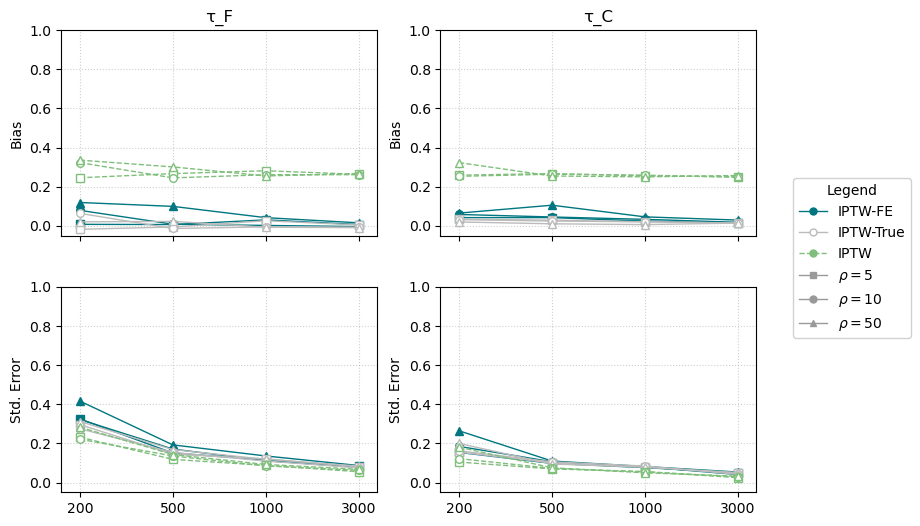

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import norm

z_90 = norm.ppf(0.95)

# -----------------------------------
# 1) Prepare long data with tau_hats
# -----------------------------------
dfp = df_results.loc[(df_results.a == 1) & (df_results.p == 2)].copy()

methods = ["IPTW-FE", "IPTW-True", "IPTW"]

tau_f_cols = {
    "IPTW-FE":   "tau_f_fe",
    "IPTW-True": "tau_f_true",
    "IPTW":      "tau_f_no_fe",
}
tau_c_cols = {
    "IPTW-FE":   "tau_c_fe",
    "IPTW-True": "tau_c_true",
    "IPTW":      "tau_c_no_fe",
}

rows = []
for _, r in dfp.iterrows():
    for m in methods:
        # τ_F
        rows.append({
            "N":       r["N"],
            "rho":     r["rho"],
            "param":   "τ_F",
            "method":  m,
            "tau_hat": r[tau_f_cols[m]],
            "tau_true": r["tau_f"],
            "seed":    r["seed"],
            "se_hat":  r[{"IPTW-FE":"tau_f_fe_se",
                         "IPTW-True":"tau_f_true_se",
                         "IPTW":"tau_f_no_fe_se"}[m]]
        })
        # τ_C
        rows.append({
            "N":       r["N"],
            "rho":     r["rho"],
            "param":   "τ_C",
            "method":  m,
            "tau_hat": r[tau_c_cols[m]],
            "tau_true": r["tau_c"],
            "seed":    r["seed"],
            "se_hat":  r[{"IPTW-FE":"tau_c_fe_se",
                         "IPTW-True":"tau_c_true_se",
                         "IPTW":"tau_c_no_fe_se"}[m]]
        })

long_df = pd.DataFrame(rows).sort_values(["param", "method", "rho", "N"])

# diffs per simulation
long_df["diff"] = long_df["tau_hat"] - long_df["tau_true"]
long_df["abs_diff"] = long_df["diff"].abs()

# 90% Wald CI using HC2 SEs
long_df["ci_low"]  = long_df["tau_hat"] - z_90 * long_df["se_hat"]
long_df["ci_high"] = long_df["tau_hat"] + z_90 * long_df["se_hat"]
long_df["covered"] = (
    (long_df["tau_true"] >= long_df["ci_low"]) &
    (long_df["tau_true"] <= long_df["ci_high"])
).astype(float)

# -----------------------------------
# 2) Aggregate over seeds
# -----------------------------------
agg_df = (
    long_df
    .groupby(["N", "rho", "param", "method"], as_index=False)
    .agg(
        bias_abs=("abs_diff", "mean"),   # mean |bias|
        std_tau=("tau_hat", "std"),       # MC std of estimator
        bias = ("diff", "mean"),        # mean bias
        coverage = ("covered", "mean")
    )
)

# -----------------------------------
# 3) Plot: 2 rows (bias, std) × 2 cols (τ_F, τ_C)
# -----------------------------------
method_ls    = {"IPTW-FE": "-", "IPTW-True": "-", "IPTW": "--"}
method_color = {"IPTW-FE": "#007680", "IPTW-True": "#BBBBBB", "IPTW": "#7FBF7B"}
rho_markers  = {5: "s", 10: "o", 50: "^"}

fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)

params = ["τ_F", "τ_C"]
unique_N = sorted(agg_df["N"].unique())
xpos = {n: i for i, n in enumerate(unique_N)}

# row specs: (row_index, column_name_in_agg_df, y_label)
rowspecs = [
    (0, "bias", "Bias"),
    (1, "std_tau",  "Std. Error"),
]

for row_idx, metric_col, ylabel in rowspecs:
    for col_idx, param in enumerate(params):
        ax = axes[row_idx, col_idx]
        sub = agg_df[agg_df["param"] == param]

        for method in methods:
            for rho, g in sub[sub["method"] == method].groupby("rho"):
                x = g["N"].map(xpos)
                ax.plot(
                    x,
                    g[metric_col],
                    linestyle=method_ls[method],
                    color=method_color[method],
                    marker=rho_markers.get(rho, "o"),
                    markerfacecolor="white" if method in ("IPTW-True", "IPTW") else method_color[method],
                    lw=1,
                    markersize=5.5,
                )

        ax.set_xticks(range(len(unique_N)))
        ax.set_xticklabels(unique_N)
        ax.set_xlim(-0.2, len(unique_N) - 0.8)
        ax.set_ylabel(ylabel)
        if row_idx == 0:
            ax.set_title(param)
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.set_ylim(-0.05, 1)

# -----------------------------------
# 4) One combined legend outside
# -----------------------------------
method_handles = [
    Line2D([0],[0], color=method_color["IPTW-FE"],   linestyle="-",  marker="o", lw=1, markersize=5, label="IPTW-FE"),
    Line2D([0],[0], color=method_color["IPTW-True"], linestyle="-",  marker="o", lw=1, markersize=5,
           markerfacecolor="white", label="IPTW-True"),
    Line2D([0],[0], color=method_color["IPTW"],      linestyle="--", marker="o", lw=1, markersize=5, label="IPTW"),
]
shape_handles = [
    Line2D([0],[0], color="0.6", linestyle="-", marker="s", lw=1, markersize=5, label=r"$\rho=5$"),
    Line2D([0],[0], color="0.6", linestyle="-", marker="o", lw=1, markersize=5, label=r"$\rho=10$"),
    Line2D([0],[0], color="0.6", linestyle="-", marker="^", lw=1, markersize=5, label=r"$\rho=50$"),
]
all_handles = method_handles + shape_handles
all_labels  = [h.get_label() for h in all_handles]

fig.legend(
    all_handles, all_labels,
    loc="center left", bbox_to_anchor=(0.85, 0.5),
    frameon=True, fancybox=True, framealpha=0.9,
    title="Legend", ncol=1,
)

fig.subplots_adjust(right=0.82, hspace=0.25)
plt.show()


In [8]:
agg_df

,N,rho,param,method,bias_abs,std_tau,bias
0,200,5,τ_C,IPTW,0.259089,0.104500,0.259089
1,200,5,τ_C,IPTW-FE,0.125687,0.153832,0.042050
2,200,5,τ_C,IPTW-True,0.121792,0.155221,0.033336
3,200,5,τ_F,IPTW,0.277165,0.231378,0.245850
4,200,5,τ_F,IPTW-FE,0.231601,0.324898,0.007607
...,...,...,...,...,...,...,...
67,3000,50,τ_C,IPTW-FE,0.048697,0.053544,0.029435
68,3000,50,τ_C,IPTW-True,0.041147,0.050989,0.013977
69,3000,50,τ_F,IPTW,0.267398,0.067407,0.267398
70,3000,50,τ_F,IPTW-FE,0.070682,0.086781,0.015317
